# Scaler를 사용해야 하는 이유
: 다차원의 변수 값을 비교분석하기 쉽게 만듬  
: 단위가 다르기 때문에 통일

# Scaler의 종류
- StandardScaler: 평균 제거, 데이터 단위를 분산으로 조정 
- MinMaxScaler: 최대/최소값이 각각 1,0이 되도록 만듬
- MaxAbsScaler: 최대절대값과 0이 각각 1,0이 되도록 만듬
- RobustScaler: 중앙값과 IQR를 사용(IQR 사용으로 이상치의 영향이 줄어듬)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글폰트설정
font_name = 'Gulim'
print(font_name)
plt.rc('font', family=font_name)

df = pd.read_csv('최종_분석데이터.csv',encoding='cp949')
df

Gulim


,grid,시도,시군구,행정동,행정동코드,법정동코드,법정동,도시재생사업수,대중교통,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,토지공시지가평균,임야공시지가평균,총공시지가평균
0,1,서울특별시,종로구,사직동,1101053,11110109,누상동,2,0.000000,101.626016,0.000936,54159.49191,21,40,0.000000,4099760.252,194850.0000,4051100.935
1,2,서울특별시,종로구,사직동,1101053,11110115,사직동,2,10007.452250,101.626016,0.000936,54159.49191,21,40,51.123292,3778295.345,195318.1818,3647355.980
2,3,서울특별시,종로구,사직동,1101053,11110115,사직동,2,9824.109813,101.626016,0.000936,54159.49191,21,40,51.123292,3778295.345,195318.1818,3647355.980
3,4,서울특별시,종로구,사직동,1101053,11110115,사직동,2,32.558804,101.626016,0.000936,54159.49191,21,40,51.123292,3778295.345,195318.1818,3647355.980
4,5,서울특별시,종로구,사직동,1101053,11110109,누상동,2,0.000000,101.626016,0.000936,54159.49191,21,40,0.000000,4099760.252,194850.0000,4051100.935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33446,75000,서울특별시,강동구,강일동,1125075,11740110,강일동,0,0.000000,1032.258065,0.002861,98420.37476,21,39,13.779205,1208408.352,436105.8824,1194059.563
33447,75001,서울특별시,강동구,강일동,1125075,11740110,강일동,0,0.000000,1032.258065,0.002861,98420.37476,21,39,13.779205,1208408.352,436105.8824,1194059.563
33448,75002,서울특별시,강동구,강일동,1125075,11740110,강일동,0,2306.248398,1032.258065,0.002861,98420.37476,21,39,13.779205,1208408.352,436105.8824,1194059.563
33449,75003,서울특별시,강동구,강일동,1125075,11740110,강일동,0,0.000000,1032.258065,0.002861,98420.37476,21,39,13.779205,1208408.352,436105.8824,1194059.563


In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33451 entries, 0 to 33450
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   grid        33451 non-null  int64  
 1   시도          33451 non-null  object 
 2   시군구         33451 non-null  object 
 3   행정동         33451 non-null  object 
 4   행정동코드       33451 non-null  int64  
 5   법정동코드       33451 non-null  int64  
 6   법정동         33451 non-null  object 
 7   도시재생사업수     33451 non-null  int64  
 8   대중교통        33451 non-null  float64
 9   기초수급자_인구밀도  33451 non-null  float64
 10  저소득층_비율     33451 non-null  float64
 11  총생활인구       33451 non-null  float64
 12  초미세먼지       33451 non-null  int64  
 13  미세먼지        33451 non-null  int64  
 14  인당녹지면적      33451 non-null  float64
 15  토지공시지가평균    33451 non-null  float64
 16  임야공시지가평균    33451 non-null  float64
 17  총공시지가평균     33451 non-null  float64
dtypes: float64(8), int64(6), object(4)
memory usage: 4.6+ MB


In [164]:
df['행정동코드']=df['행정동코드'].astype(object)
df['법정동코드']=df['법정동코드'].astype(object)
df['grid']=df['grid'].astype(object)

{'whiskers': [<matplotlib.lines.Line2D at 0x198319d2940>,
 'caps': [<matplotlib.lines.Line2D at 0x198319d2ee0>,
 'boxes': [<matplotlib.lines.Line2D at 0x198319d2670>,
 'medians': [<matplotlib.lines.Line2D at 0x198319df4c0>,
 'fliers': [<matplotlib.lines.Line2D at 0x198319df790>,
 'means': []}

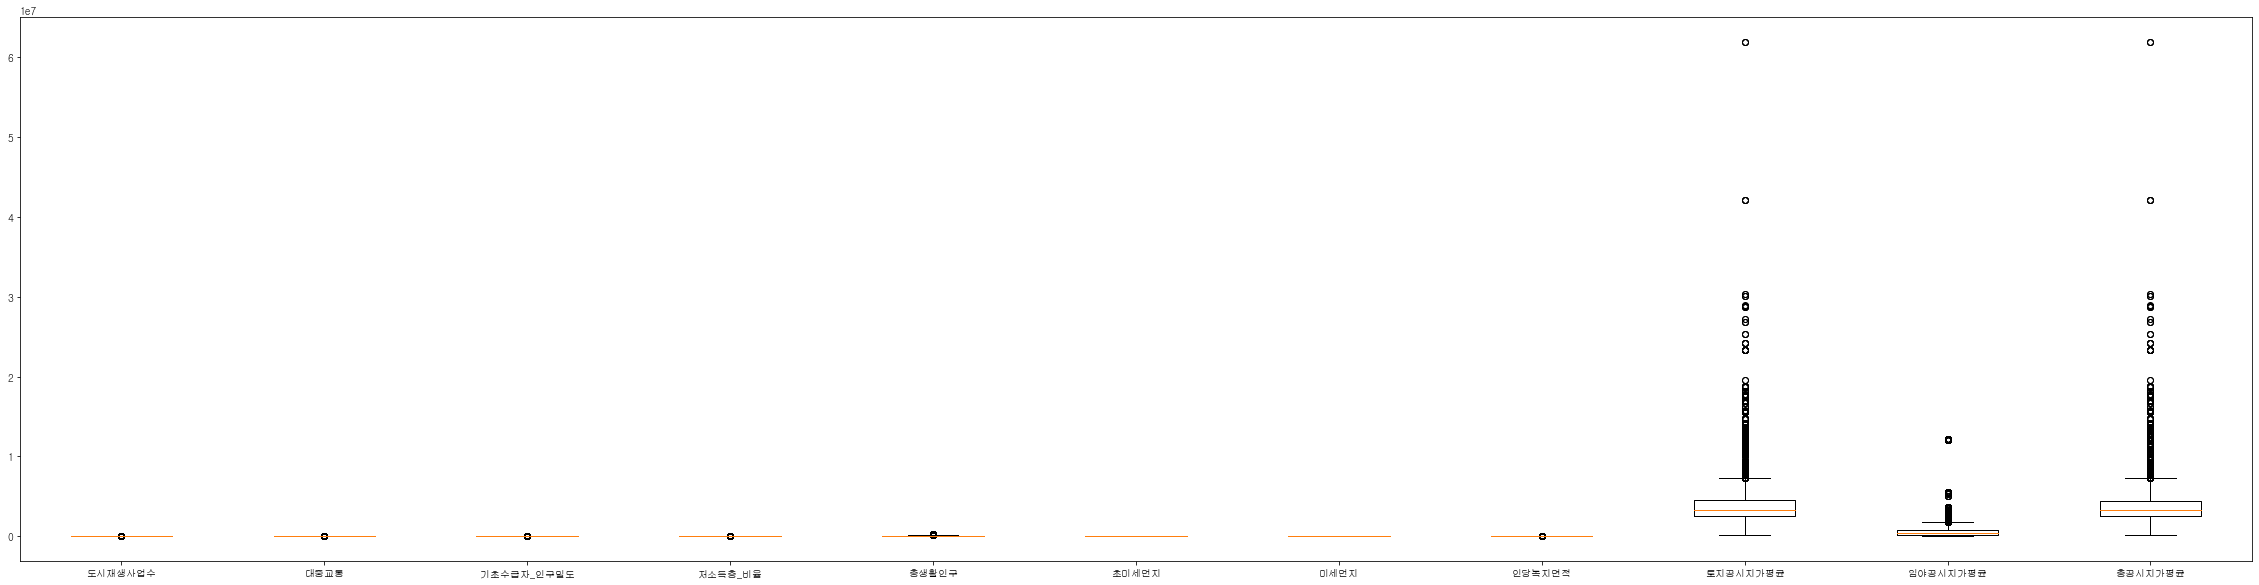

In [168]:
plt.rcParams['figure.figsize'] = (40, 10)

fig=plt.figure() 
ax=fig.add_subplot(1,1,1)
ax.boxplot(df.iloc[:,7:], labels=df.iloc[:,7:].columns)

# 공시지가 데이터 단위가 커 scaler 적용이 필요하다는 것을 확인

# 1. StandarScaler|

In [172]:
from sklearn.preprocessing import StandardScaler 

std_scaler = StandardScaler() 
standardScaled_data = std_scaler.fit_transform(df.iloc[:,7:]) 
standardScaled_data

array([[ 2.00333537, -0.58973849, -0.71546933, ..., -0.01098062,
        -0.44784761,  0.0087311 ],
       [ 2.00333537,  1.94963711, -0.71546933, ..., -0.12079215,
        -0.44733997, -0.12890109],
       [ 2.00333537,  1.90311425, -0.71546933, ..., -0.12079215,
        -0.44733997, -0.12890109],
       ...,
       [-0.45321887, -0.00453151,  0.43073001, ..., -0.99865848,
        -0.18625479, -0.96520265],
       [-0.45321887, -0.58973849,  0.43073001, ..., -0.99865848,
        -0.18625479, -0.96520265],
       [-0.45321887, -0.58973849,  0.43073001, ..., -0.99865848,
        -0.18625479, -0.96520265]])

{'whiskers': [<matplotlib.lines.Line2D at 0x198342d7c40>,
 'caps': [<matplotlib.lines.Line2D at 0x198342e7220>,
 'boxes': [<matplotlib.lines.Line2D at 0x198342d7970>,
 'medians': [<matplotlib.lines.Line2D at 0x198342e77c0>,
 'fliers': [<matplotlib.lines.Line2D at 0x198342e7a90>,
 'means': []}

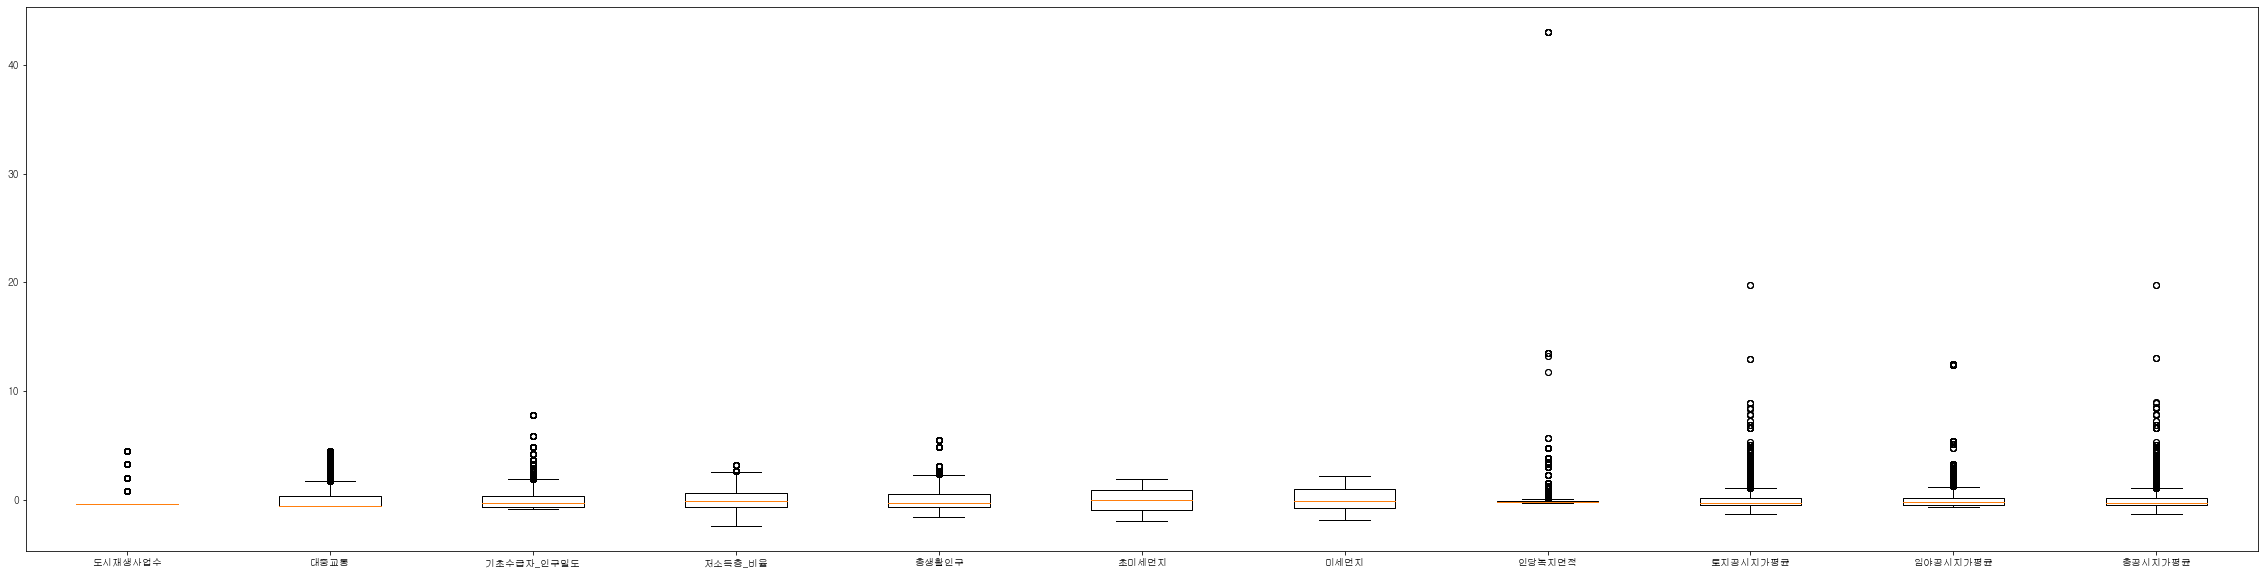

In [173]:
plt.rcParams['figure.figsize'] = (40, 10)

fig=plt.figure() 
ax=fig.add_subplot(1,1,1)
ax.boxplot(standardScaled_data, labels=df.iloc[:,7:].columns)

[Text(0, 0, '도시재생사업수'),
 Text(0, 1, '대중교통'),
 Text(0, 2, '기초수급자_인구밀도'),
 Text(0, 3, '저소득층_비율'),
 Text(0, 4, '총생활인구'),
 Text(0, 5, '초미세먼지'),
 Text(0, 6, '미세먼지'),
 Text(0, 7, '인당녹지면적'),
 Text(0, 8, '토지공시지가평균'),
 Text(0, 9, '임야공시지가평균'),
 Text(0, 10, '총공시지가평균')]

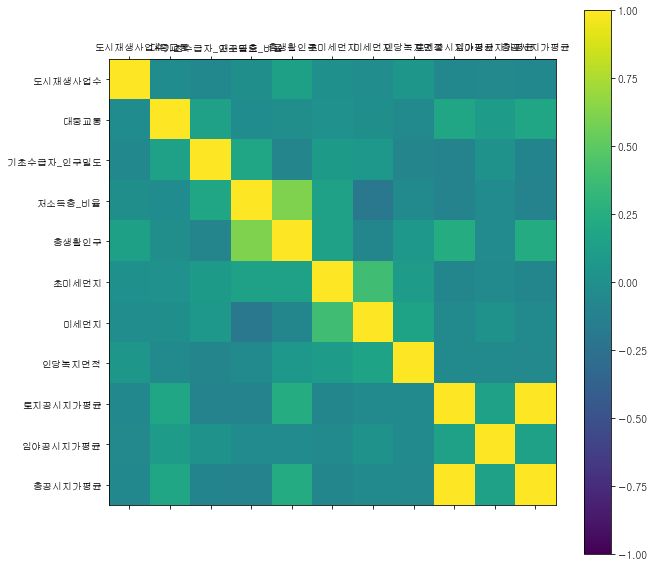

In [175]:
import numpy as np
corr_data = np.corrcoef(standardScaled_data.T)
corr_data

fig = plt.figure(figsize=(10,10))
ax=fig.add_subplot(111)
cax = ax.matshow(corr_data, vmin=-1, vmax=1, interpolation='nearest') 
fig.colorbar(cax)
ticks=np.arange(0,corr_data.shape[0],1)
ax.set_xticks(ticks) 
ax.set_yticks(ticks) 
ax.set_xticklabels(df.iloc[:,7:].columns) 
ax.set_yticklabels(df.iloc[:,7:].columns)


# 2. MinMaxScaler

In [176]:
from sklearn.preprocessing import MinMaxScaler

minMaxScaler = MinMaxScaler()
minMaxScaled_data = minMaxScaler.fit_transform(df.iloc[:,7:]) 
minMaxScaled_data

array([[0.5       , 0.        , 0.01433485, ..., 0.06331076, 0.01602385,
        0.06252355],
       [0.5       , 0.49998457, 0.01433485, ..., 0.05810459, 0.01606235,
        0.05598485],
       [0.5       , 0.49082456, 0.01433485, ..., 0.05810459, 0.01606235,
        0.05598485],
       ...,
       [0.        , 0.11522299, 0.14787057, ..., 0.01648491, 0.03586397,
        0.01625341],
       [0.        , 0.        , 0.14787057, ..., 0.01648491, 0.03586397,
        0.01625341],
       [0.        , 0.        , 0.14787057, ..., 0.01648491, 0.03586397,
        0.01625341]])

{'whiskers': [<matplotlib.lines.Line2D at 0x1982242e190>,
 'caps': [<matplotlib.lines.Line2D at 0x1982242e730>,
 'boxes': [<matplotlib.lines.Line2D at 0x1983763fe80>,
 'medians': [<matplotlib.lines.Line2D at 0x1982242ecd0>,
 'fliers': [<matplotlib.lines.Line2D at 0x1982242efa0>,
 'means': []}

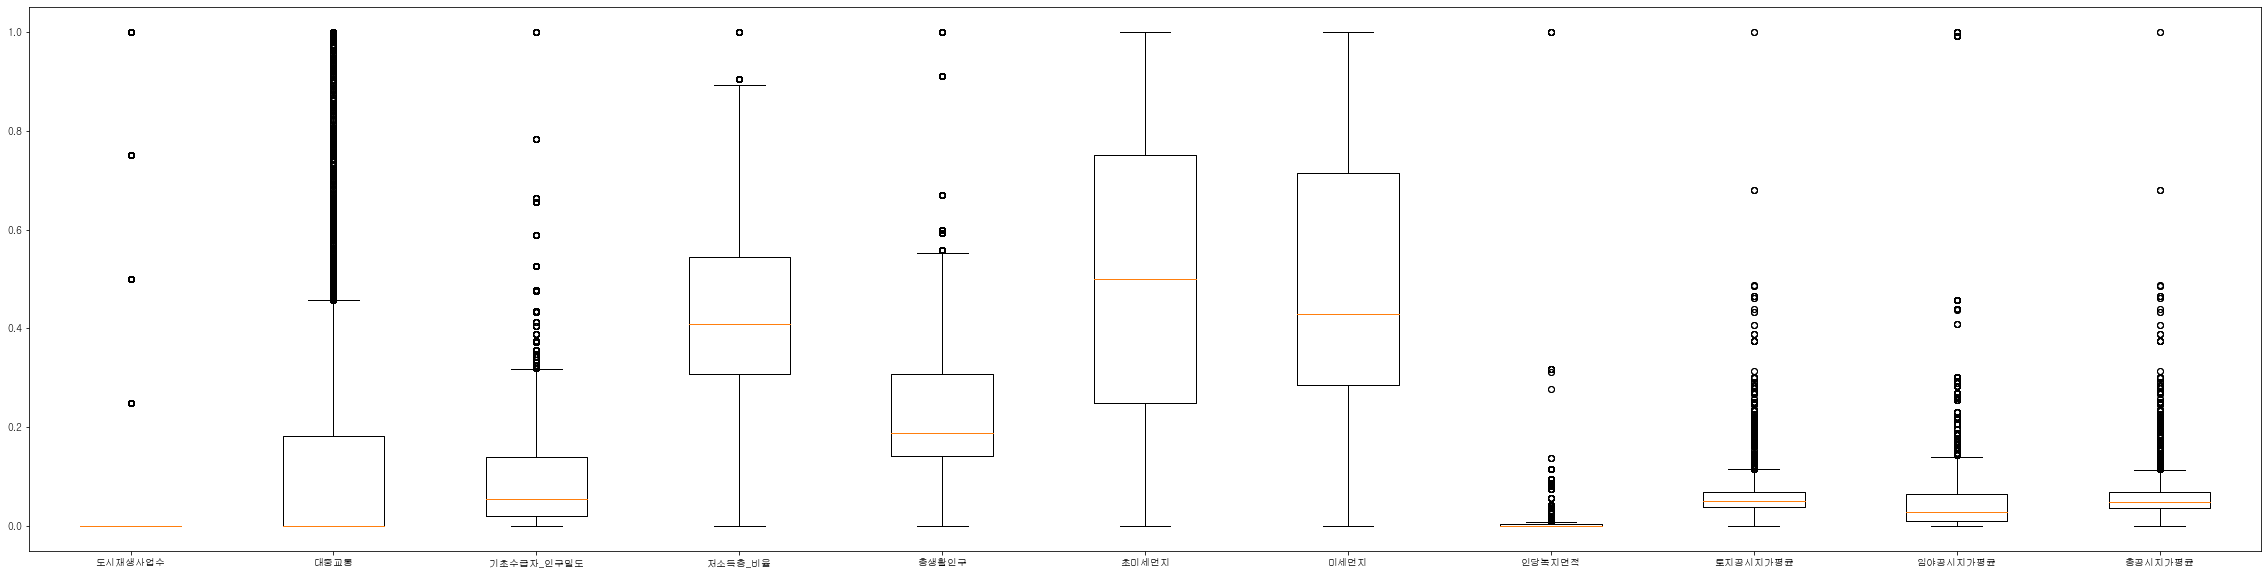

In [177]:
plt.rcParams['figure.figsize'] = (40, 10)

fig=plt.figure() 
ax=fig.add_subplot(1,1,1)
ax.boxplot(minMaxScaled_data, labels=df.iloc[:,7:].columns)

# 3. MaxAbsScaler

In [178]:
from sklearn.preprocessing import MaxAbsScaler

maxAbsScaler = MaxAbsScaler()
maxAbsScaled_data = maxAbsScaler.fit_transform(df.iloc[:,7:]) 
maxAbsScaled_data

array([[0.5       , 0.        , 0.01457864, ..., 0.06619196, 0.01602385,
        0.06540633],
       [0.5       , 0.49998457, 0.01457864, ..., 0.0610018 , 0.01606235,
        0.05888774],
       [0.5       , 0.49082456, 0.01457864, ..., 0.0610018 , 0.01606235,
        0.05888774],
       ...,
       [0.        , 0.11522299, 0.14808133, ..., 0.01951014, 0.03586397,
        0.01927848],
       [0.        , 0.        , 0.14808133, ..., 0.01951014, 0.03586397,
        0.01927848],
       [0.        , 0.        , 0.14808133, ..., 0.01951014, 0.03586397,
        0.01927848]])

{'whiskers': [<matplotlib.lines.Line2D at 0x19822554e80>,
 'caps': [<matplotlib.lines.Line2D at 0x19811132460>,
 'boxes': [<matplotlib.lines.Line2D at 0x19822554b20>,
 'medians': [<matplotlib.lines.Line2D at 0x19811132a00>,
 'fliers': [<matplotlib.lines.Line2D at 0x19811132cd0>,
 'means': []}

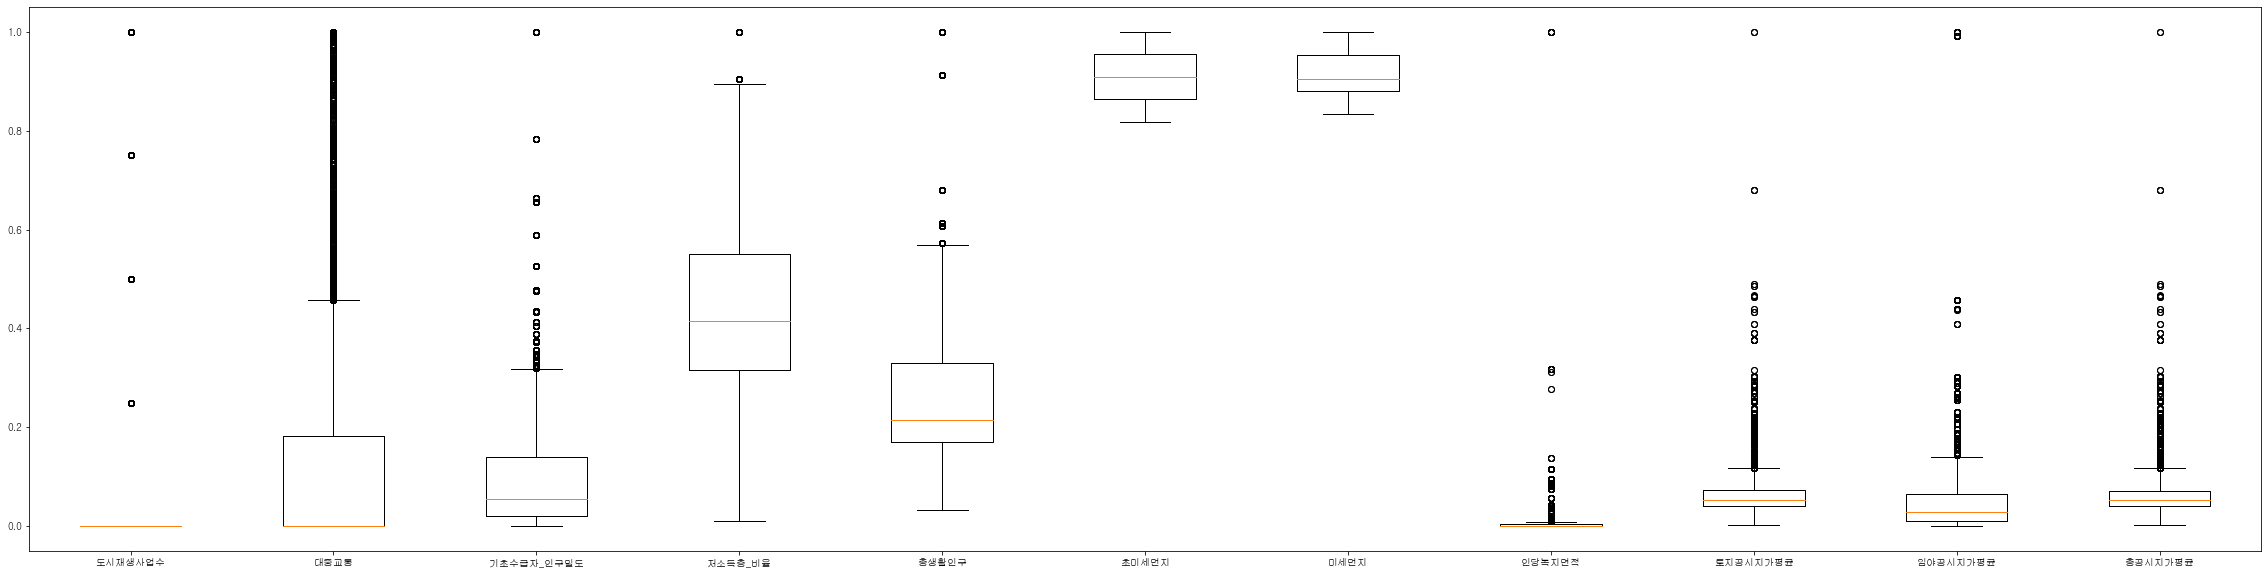

In [179]:
plt.rcParams['figure.figsize'] = (40, 10)

fig=plt.figure() 
ax=fig.add_subplot(1,1,1)
ax.boxplot(maxAbsScaled_data, labels=df.iloc[:,7:].columns)

# 4. RobustScaler

In [181]:
from sklearn.preprocessing import RobustScaler

robustScaler = RobustScaler()
robustScaled_data = robustScaler.fit_transform(df.iloc[:,7:]) 
robustScaled_data

array([[ 2.        ,  0.        , -0.34281585, ...,  0.42775493,
        -0.24475723,  0.44167707],
       [ 2.        ,  2.72771183, -0.34281585, ...,  0.2590392 ,
        -0.2440411 ,  0.2302213 ],
       [ 2.        ,  2.67773853, -0.34281585, ...,  0.2590392 ,
        -0.2440411 ,  0.2302213 ],
       ...,
       [ 0.        ,  0.62860965,  0.77546927, ..., -1.08972498,
         0.12426444, -1.05465837],
       [ 0.        ,  0.        ,  0.77546927, ..., -1.08972498,
         0.12426444, -1.05465837],
       [ 0.        ,  0.        ,  0.77546927, ..., -1.08972498,
         0.12426444, -1.05465837]])

{'whiskers': [<matplotlib.lines.Line2D at 0x198118041f0>,
 'caps': [<matplotlib.lines.Line2D at 0x19811804790>,
 'boxes': [<matplotlib.lines.Line2D at 0x1981177dee0>,
 'medians': [<matplotlib.lines.Line2D at 0x19811804d30>,
 'fliers': [<matplotlib.lines.Line2D at 0x1981180c040>,
 'means': []}

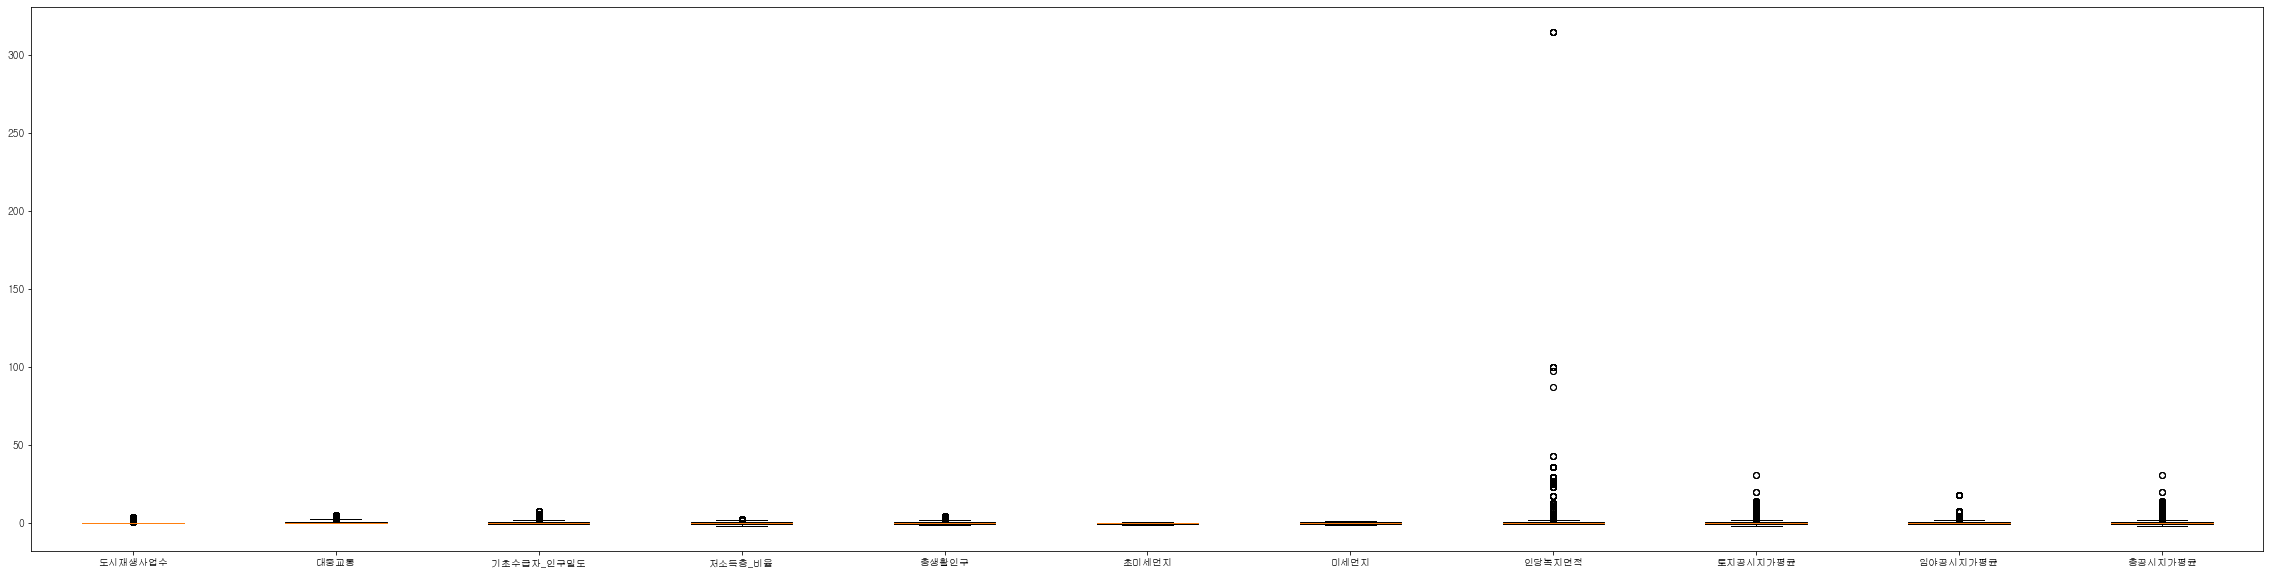

In [182]:
plt.rcParams['figure.figsize'] = (40, 10)

fig=plt.figure() 
ax=fig.add_subplot(1,1,1)
ax.boxplot(robustScaled_data, labels=df.iloc[:,7:].columns)

# 결론: MinMaxScaler로 하자!

In [106]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글폰트설정
font_name = 'Gulim'
print(font_name)
plt.rc('font', family=font_name)

df = pd.read_csv('최종_분석데이터.csv',encoding='cp949')

df['행정동코드']=df['행정동코드'].astype(object)
df['법정동코드']=df['법정동코드'].astype(object)
df['grid']=df['grid'].astype(object)

df

Gulim


,grid,시도,시군구,행정동,행정동코드,법정동코드,법정동,도시재생사업수,대중교통,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,토지공시지가평균,임야공시지가평균,총공시지가평균
0,1,서울특별시,종로구,사직동,1101053,11110109,누상동,2,0.000000,101.626016,0.000936,54159.49191,21,40,0.000000,4099760.252,194850.0000,4051100.935
1,2,서울특별시,종로구,사직동,1101053,11110115,사직동,2,10007.452250,101.626016,0.000936,54159.49191,21,40,51.123292,3778295.345,195318.1818,3647355.980
2,3,서울특별시,종로구,사직동,1101053,11110115,사직동,2,9824.109813,101.626016,0.000936,54159.49191,21,40,51.123292,3778295.345,195318.1818,3647355.980
3,4,서울특별시,종로구,사직동,1101053,11110115,사직동,2,32.558804,101.626016,0.000936,54159.49191,21,40,51.123292,3778295.345,195318.1818,3647355.980
4,5,서울특별시,종로구,사직동,1101053,11110109,누상동,2,0.000000,101.626016,0.000936,54159.49191,21,40,0.000000,4099760.252,194850.0000,4051100.935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33446,75000,서울특별시,강동구,강일동,1125075,11740110,강일동,0,0.000000,1032.258065,0.002861,98420.37476,21,39,13.779205,1208408.352,436105.8824,1194059.563
33447,75001,서울특별시,강동구,강일동,1125075,11740110,강일동,0,0.000000,1032.258065,0.002861,98420.37476,21,39,13.779205,1208408.352,436105.8824,1194059.563
33448,75002,서울특별시,강동구,강일동,1125075,11740110,강일동,0,2306.248398,1032.258065,0.002861,98420.37476,21,39,13.779205,1208408.352,436105.8824,1194059.563
33449,75003,서울특별시,강동구,강일동,1125075,11740110,강일동,0,0.000000,1032.258065,0.002861,98420.37476,21,39,13.779205,1208408.352,436105.8824,1194059.563


- 변수별 이상치 제거

{'whiskers': [<matplotlib.lines.Line2D at 0x193a185eaf0>,
 'caps': [<matplotlib.lines.Line2D at 0x193a186e0d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x193a185e820>,
 'medians': [<matplotlib.lines.Line2D at 0x193a186e670>,
 'fliers': [<matplotlib.lines.Line2D at 0x193a186e940>,
 'means': []}

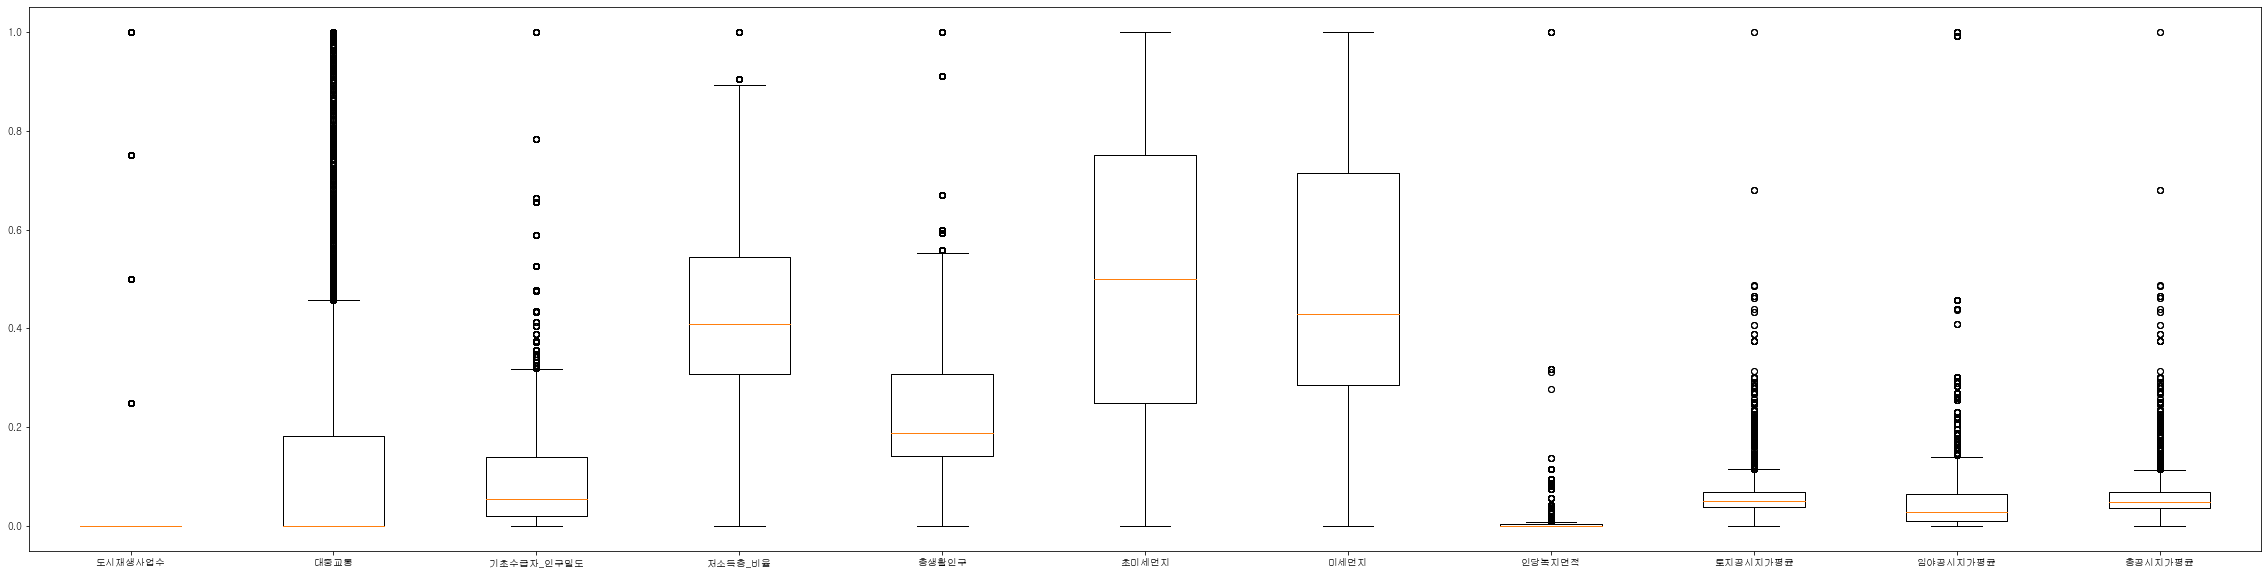

In [107]:
from sklearn.preprocessing import MinMaxScaler

minMaxScaler = MinMaxScaler()
minMaxScaled_data = minMaxScaler.fit_transform(df.iloc[:,7:]) 

import seaborn as sns

plt.rcParams['figure.figsize'] = (40, 10)

fig=plt.figure() 
ax=fig.add_subplot(1,1,1)
ax.boxplot(minMaxScaled_data, labels=df.iloc[:,7:].columns)

<기준>
- 도시재생사업수: 안뺌
- 버스는 2/3가 0이어서 이상치를 측정할 수 없었음. 그래서 0빼고 박스플랏 그려봤더니 이상치 없었음.
- 기초수급자 인구밀도,총생활인구수: 너무 높은 이상치 두 개 제거
- 저소득층: 너무 높은 이상치 하나 제거
- 공시지가: 이상치 전부제거 + 0.75 이상은 후보지에서 제거

### 이상치 제거

#### 1. 기초수급자_인구밀도
강서구 등촌3동 6970.886076  
노원구 중계2.3동 5466.666667  
ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ  
강서구 가양3동 4624.0  

In [108]:
# 가장 큰 값 제거 - 2번
df = df[df.기초수급자_인구밀도 != df.기초수급자_인구밀도.max()]
df = df[df.기초수급자_인구밀도 != df.기초수급자_인구밀도.max()]

#### 2. 저소득층_비율
강서구 화곡1동 0.005823   
동작구 상도1동 0.005273  
ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ  
강동구 길동 108205.7457	

In [109]:
# 가장 큰 값 제거 - 2번
df = df[df.저소득층_비율 != df.저소득층_비율.max()]
df = df[df.저소득층_비율 != df.저소득층_비율.max()]

#### 3. 총생활인구
강남구 역삼동 214439.7705  
영등포구 여의동 195875.6519	 
ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ  
마포구 서교동 146020.0495

In [110]:
df = df[df.총생활인구 != df.총생활인구.max()]
df = df[df.총생활인구 != df.총생활인구.max()]

#### 4. 인당녹지면적  
max = 4.310339892515737

In [111]:
df['인당녹지면적'] = np.log1p(df['인당녹지면적'])
quantile_75 = np.quantile(df['인당녹지면적'],0.75)

IQR = quantile_75 - quantile_25

maximum = quantile_75 + 1.5 * IQR

df = df[(df['인당녹지면적'] <= maximum)]

#### 5. 토지 공시지가
max = 16.10510846562331  
min = 13.947365496491562

In [112]:
import numpy as np
df['토지공시지가평균'] = np.log1p(df['토지공시지가평균'])
quantile_25 = np.quantile(df['토지공시지가평균'], 0.25)
quantile_75 = np.quantile(df['토지공시지가평균'],0.75)

IQR = quantile_75 - quantile_25

minimum = quantile_25 - 1.5 * IQR
maximum = quantile_75 + 1.5 * IQR

df = df[(minimum <= df['토지공시지가평균']) & (df['토지공시지가평균'] <= maximum)]

#### 6. 임야 공시지가  
max = 15.871898316574452  
min = 9.720732284151467

In [113]:
import numpy as np
df['임야공시지가평균'] = np.log1p(df['임야공시지가평균'])
quantile_25 = np.quantile(df['임야공시지가평균'], 0.25)
quantile_75 = np.quantile(df['임야공시지가평균'],0.75)

IQR = quantile_75 - quantile_25

minimum = quantile_25 - 1.5 * IQR
maximum = quantile_75 + 1.5 * IQR

df = df[(minimum <= df['임야공시지가평균']) & (df['임야공시지가평균'] <= maximum)]

#### 7. 총 공시지가  
max = 15.999166267597197   
min = 13.92327075506708

In [114]:
import numpy as np
df['총공시지가평균'] = np.log1p(df['총공시지가평균'])
quantile_25 = np.quantile(df['총공시지가평균'], 0.25)
quantile_75 = np.quantile(df['총공시지가평균'],0.75)

IQR = quantile_75 - quantile_25

minimum = quantile_25 - 1.5 * IQR
maximum = quantile_75 + 1.5 * IQR

df = df[(minimum <= df['총공시지가평균']) & (df['총공시지가평균'] <= maximum)]

# 결과

{'whiskers': [<matplotlib.lines.Line2D at 0x193a1cbe9a0>,
 'caps': [<matplotlib.lines.Line2D at 0x193a1cbef40>,
 'boxes': [<matplotlib.lines.Line2D at 0x193a1cbe6d0>,
 'medians': [<matplotlib.lines.Line2D at 0x193a1cce520>,
 'fliers': [<matplotlib.lines.Line2D at 0x193a1cce7f0>,
 'means': []}

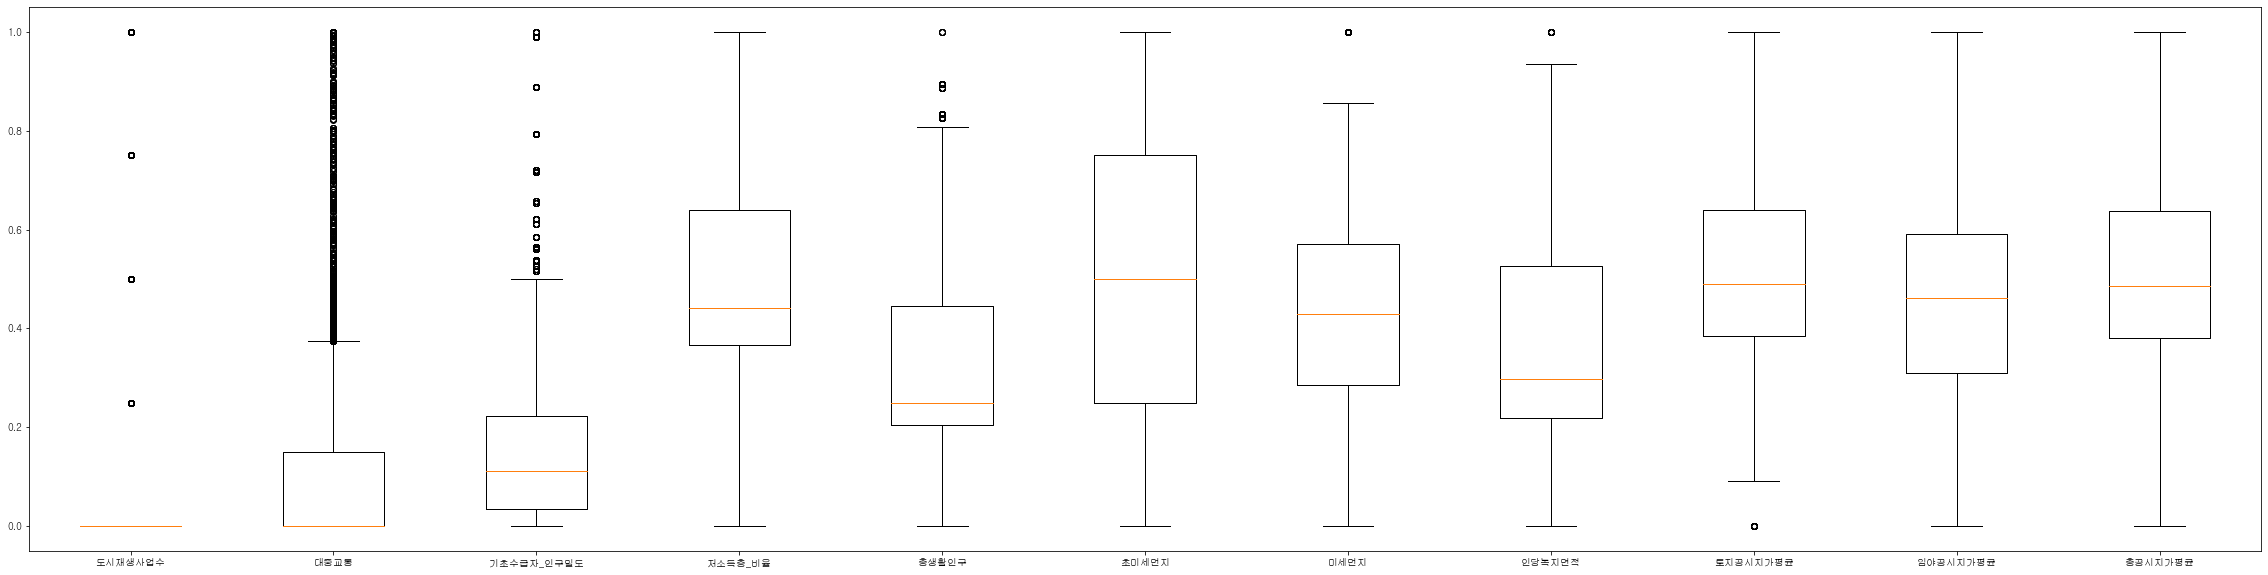

In [115]:
from sklearn.preprocessing import MinMaxScaler

minMaxScaler = MinMaxScaler()
minMaxScaled_data = minMaxScaler.fit_transform(df.iloc[:,7:]) 

import seaborn as sns

plt.rcParams['figure.figsize'] = (40, 10)

fig=plt.figure() 
ax=fig.add_subplot(1,1,1)
ax.boxplot(minMaxScaled_data, labels=df.iloc[:,7:].columns)

In [118]:
df.shape

(25956, 18)